In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter1d
import kmapper as km
from kmapper import jupyter
import networkx as nx
from ripser import ripser
from persim import plot_diagrams
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Custom Style
# Add lib folder to path to import viz_style
sys.path.append(os.path.join(os.getcwd(), 'lib'))
try:
    import viz_style
except ImportError:
    from lib import viz_style

viz_style.set_architectural_style()

print("Libraries imported.")

Architectural plot style applied (Dark Mode).
Libraries imported.


In [ ]:
# --- 1. Load Data (CA1) ---
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

session_id = 715093703 # Using the session from previous examples
print(f"Loading Session {session_id}...")
session = cache.get_session_data(session_id)

# Filter for CA1 Units with Quality Metrics
region_acronym = "CA1"
isi_threshold = 0.5
amplitude_cutoff_threshold = 0.1
presence_ratio_threshold = 0.9

units = session.units[
    (session.units["ecephys_structure_acronym"] == region_acronym) &
    (session.units["isi_violations"] < isi_threshold) &
    (session.units["amplitude_cutoff"] < amplitude_cutoff_threshold) &
    (session.units["presence_ratio"] > presence_ratio_threshold)
]
print(f"Selected {len(units)} units from {region_acronym} (Quality Filtered)")

# Construct Neural Response Matrix
movie_table = session.get_stimulus_table("natural_movie_one")
frame_duration = movie_table['duration'].mean()

print("Calculating spike counts...")
spike_counts_xr = session.presentationwise_spike_counts(
    stimulus_presentation_ids=movie_table.index.values,
    bin_edges=np.array([0, frame_duration]),
    unit_ids=units.index.values
)

response_matrix_all = spike_counts_xr.sum(dim="time_relative_to_stimulus_onset")

df_response = pd.DataFrame(
    response_matrix_all.values,
    index=movie_table.index,
    columns=units.index
)
df_response['frame'] = movie_table['frame']
average_response_matrix = df_response.groupby('frame').mean()

# Smoothing (Important for intrinsic dimensionality)
X_raw = average_response_matrix.values
sigma = 2.0 # Smooth over 2 frames (~60ms)
X_smooth = gaussian_filter1d(X_raw, sigma=sigma, axis=0)

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X_smooth)

print(f"Data Shape (Frames x Neurons): {X.shape}")

Loading Session 715093703...
Selected 145 units from CA1 (Quality Filtered)
Selected 145 units from CA1 (Quality Filtered)
Calculating spike counts...
Data Shape (Frames x Neurons): (900, 145)


Estimating local dimensionality (k=50, var_thresh=0.9)...
Local Dimension Stats: Mean=12.83, Median=13.0, Min=10.0, Max=17.0
Local Dimension Stats: Mean=12.83, Median=13.0, Min=10.0, Max=17.0


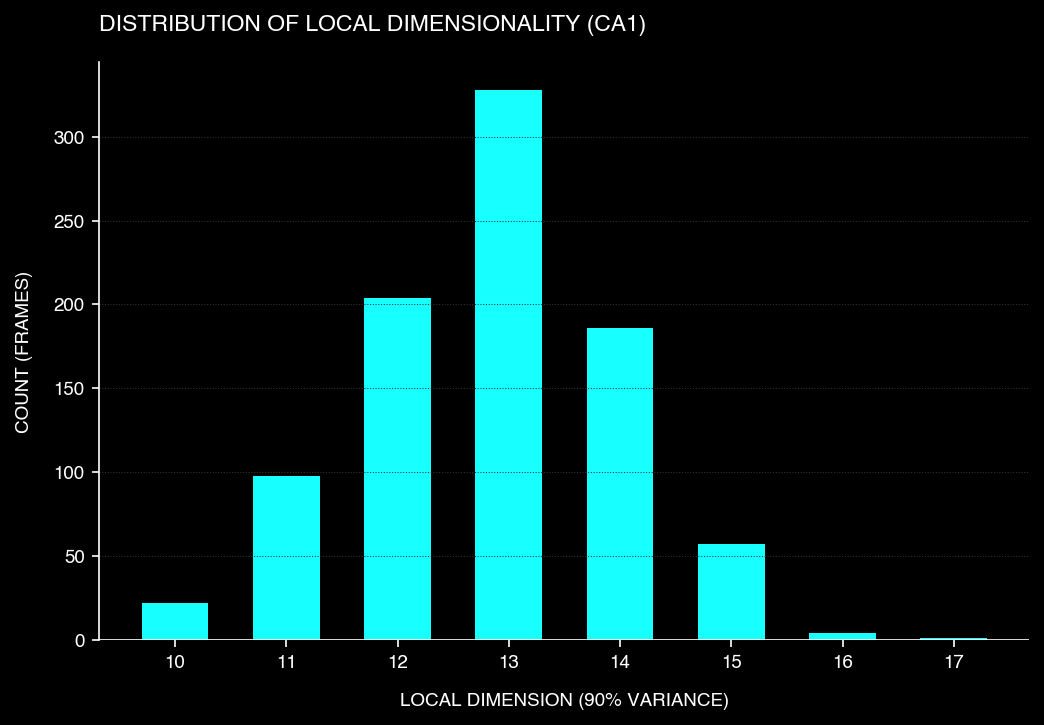

In [ ]:
# --- 2. Intrinsic Dimensionality (Local PCA) ---
# Calculate the 'local dimensionality' at each point on the manifold.

def estimate_local_dimension(data, k=30, variance_threshold=0.90):
    """
    Estimates local dimensionality for each point using PCA on k-nearest neighbors.
    Returns the number of components needed to explain `variance_threshold` of local variance.
    """
    n_samples = data.shape[0]
    local_dims = np.zeros(n_samples)
    
    nbrs = NearestNeighbors(n_neighbors=k).fit(data)
    _, indices = nbrs.kneighbors(data)
    
    print(f"Estimating local dimensionality (k={k}, var_thresh={variance_threshold})...")
    for i in range(n_samples):
        # Get local neighborhood
        local_cloud = data[indices[i]]
        
        # Center the local cloud
        local_cloud = local_cloud - local_cloud.mean(axis=0)
        
        # PCA
        pca = PCA()
        pca.fit(local_cloud)
        
        # Count components
        cumsum = np.cumsum(pca.explained_variance_ratio_)
        dim = np.searchsorted(cumsum, variance_threshold) + 1
        local_dims[i] = dim
        
    return local_dims

local_dims = estimate_local_dimension(X, k=50, variance_threshold=0.90)

print(f"Local Dimension Stats: Mean={np.mean(local_dims):.2f}, Median={np.median(local_dims)}, Min={np.min(local_dims)}, Max={np.max(local_dims)}")

# Histogram of Local Dimensions
fig, ax = plt.subplots(figsize=(8, 5))
viz_style.plot_bar(ax, 
                   x=np.arange(int(np.min(local_dims)), int(np.max(local_dims))+1), 
                   y=[np.sum(local_dims == d) for d in range(int(np.min(local_dims)), int(np.max(local_dims))+1)],
                   color=viz_style.CYAN,
                   title="DISTRIBUTION OF LOCAL DIMENSIONALITY (CA1)",
                   xlabel="Local Dimension (90% Variance)",
                   ylabel="Count (Frames)")
plt.show()

Running Isomap (Geodesic Embedding)...


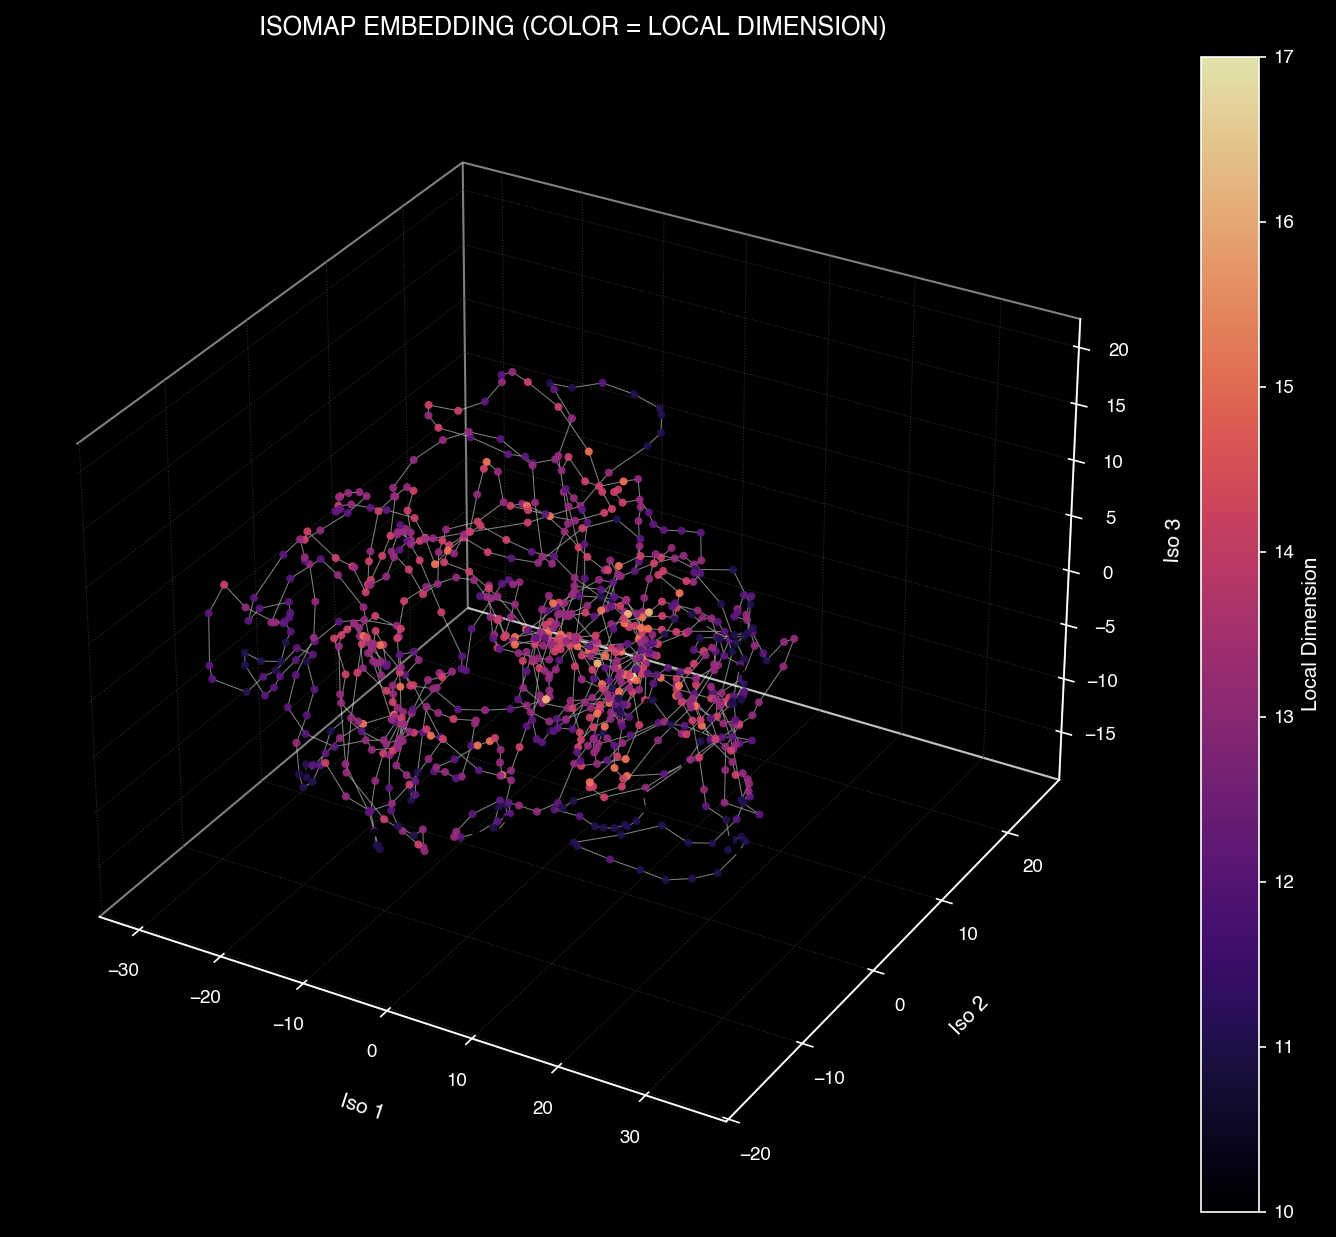

In [ ]:
# --- 3. Geodesic Embedding (Isomap) ---
# Use Isomap to unfold the manifold based on geodesic distances.

print("Running Isomap (Geodesic Embedding)...")
n_neighbors = 30
isomap = Isomap(n_neighbors=n_neighbors, n_components=3)
X_iso = isomap.fit_transform(X)

# Visualize Isomap colored by Local Dimensionality
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

sc = viz_style.plot_3d_trajectory(
    ax,
    X_iso[:, 0], X_iso[:, 1], X_iso[:, 2],
    c=local_dims,
    cmap='magma',
    title=f"ISOMAP EMBEDDING (Color = Local Dimension)",
    xlabel="Iso 1", ylabel="Iso 2", zlabel="Iso 3"
)
cbar = plt.colorbar(sc, ax=ax, label="Local Dimension")
cbar.ax.yaxis.label.set_color(viz_style.WHITE)
cbar.ax.tick_params(colors=viz_style.WHITE)
plt.show()

Running Ripser on Raw Unit Data (X)...


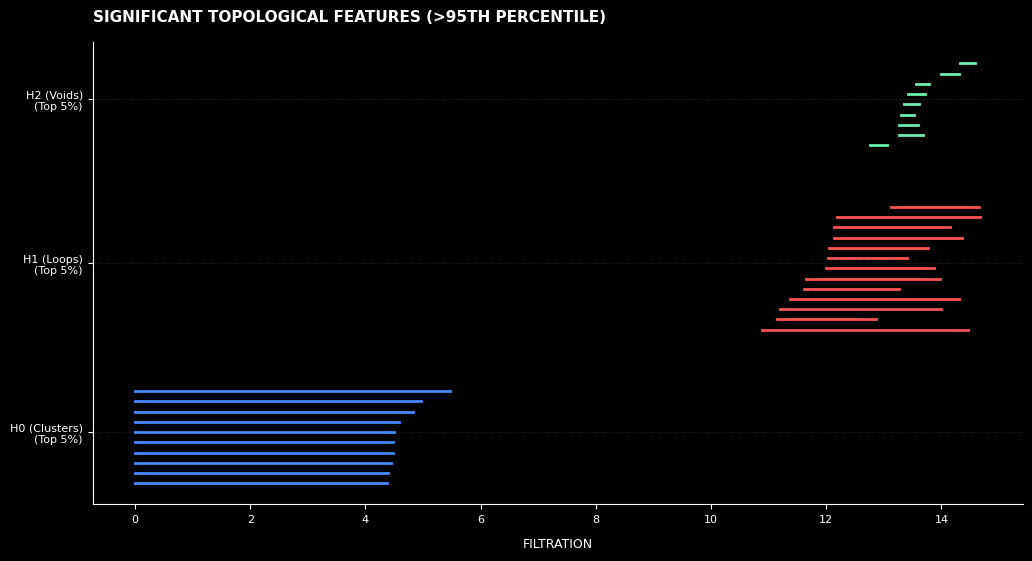

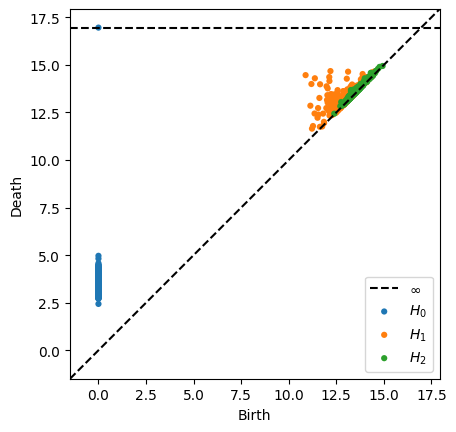

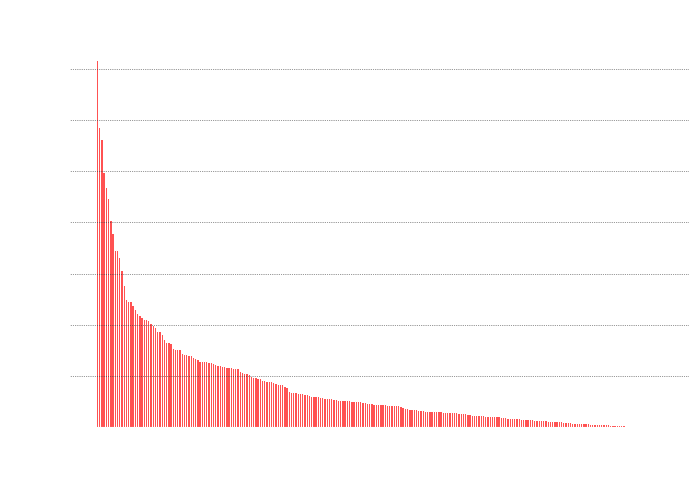

Found 13 dominant loops (>95th percentile persistence).


In [ ]:
# --- 4. Persistent Homology (Raw Unit Data) ---
# We perform Persistent Homology directly on the high-dimensional unit response vectors (X).
# This avoids any dimensionality reduction assumptions (like PCA, ISOMAP, UMAP).

print("Running Ripser on Raw Unit Data (X)...")
# maxdim=2 to include voids (H2). Note: This might be computationally intensive.
result = ripser(X, maxdim=2) 
diagrams = result['dgms']

# Filter for Significant Features (Long Bars)
def plot_filtered_barcode(diagrams, percentile=90):
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(viz_style.BLACK)
    ax.set_facecolor(viz_style.BLACK)
    
    colors = [viz_style.BLUE, viz_style.RED, viz_style.GREEN]
    labels = ["H0 (Clusters)", "H1 (Loops)", "H2 (Voids)"]
    
    current_y = 0
    ytick_locs = []
    ytick_labels = []
    
    for i, dgm in enumerate(diagrams):
        if len(dgm) == 0: continue
        
        # Calculate lifetimes
        lifetimes = dgm[:, 1] - dgm[:, 0]
        finite_mask = np.isfinite(lifetimes)
        
        if np.sum(finite_mask) == 0:
            threshold = 0
        else:
            threshold = np.percentile(lifetimes[finite_mask], percentile)
            
        # Filter
        if i == 0: # Keep all H0 or just significant ones? Usually H0 is less interesting for thresholding
             significant_indices = np.argsort(dgm[:, 1] - dgm[:, 0])[-10:] # Top 10 H0
        else:
             significant_indices = np.where(lifetimes > threshold)[0]
        
        dgm_sig = dgm[significant_indices]
        
        # Sort by birth
        dgm_sig = dgm_sig[np.argsort(dgm_sig[:, 0])]
        
        for j, (birth, death) in enumerate(dgm_sig):
            y = current_y + j
            if np.isinf(death): death = np.max(dgm[np.isfinite(dgm)]) * 1.1
            ax.plot([birth, death], [y, y], color=colors[i], linewidth=2)
            
        ytick_locs.append(current_y + len(dgm_sig)/2)
        ytick_labels.append(f"{labels[i]}\n(Top {100-percentile}%)")
        current_y += len(dgm_sig) + 5
        
    ax.set_yticks(ytick_locs)
    ax.set_yticklabels(ytick_labels, color=viz_style.WHITE)
    viz_style.format_axis(ax, title=f"SIGNIFICANT TOPOLOGICAL FEATURES (>{percentile}th Percentile)", xlabel="Filtration")
    plt.show()

plot_filtered_barcode(diagrams, percentile=95)
plot_diagrams(diagrams, show=True)

# --- A. Loop Structure Quantification ---
# Histogram of H1 Lifetimes
h1_dgm = diagrams[1]
if len(h1_dgm) > 0:
    lifetimes = h1_dgm[:, 1] - h1_dgm[:, 0]
    finite_lifetimes = lifetimes[np.isfinite(lifetimes)]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    # Sort lifetimes descending
    sorted_lifetimes = np.sort(finite_lifetimes)[::-1]
    
    viz_style.plot_bar(ax, 
                       x=np.arange(len(sorted_lifetimes)), 
                       y=sorted_lifetimes,
                       color=viz_style.RED,
                       title="H1 (LOOP) LIFETIME DISTRIBUTION",
                       xlabel="Rank (Sorted by Persistence)",
                       ylabel="Persistence (Lifetime)")
    plt.show()
    
    # Identify Dominant Loops
    threshold = np.percentile(finite_lifetimes, 95)
    n_dominant = np.sum(finite_lifetimes > threshold)
    print(f"Found {n_dominant} dominant loops (>95th percentile persistence).")

Running Mapper...
KeplerMapper(verbose=1)
..Composing projection pipeline of length 1:
	Projections: Isomap(n_neighbors=30)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (900, 145)

..Projecting data using: 
	Isomap(n_neighbors=30)


..Scaling with: MinMaxScaler()

Mapping on data shaped (900, 145) using lens shaped (900, 2)

Creating 100 hypercubes.

Created 342 edges and 272 nodes in 0:00:00.157836.

..Scaling with: MinMaxScaler()

Mapping on data shaped (900, 145) using lens shaped (900, 2)

Creating 100 hypercubes.

Created 342 edges and 272 nodes in 0:00:00.157836.


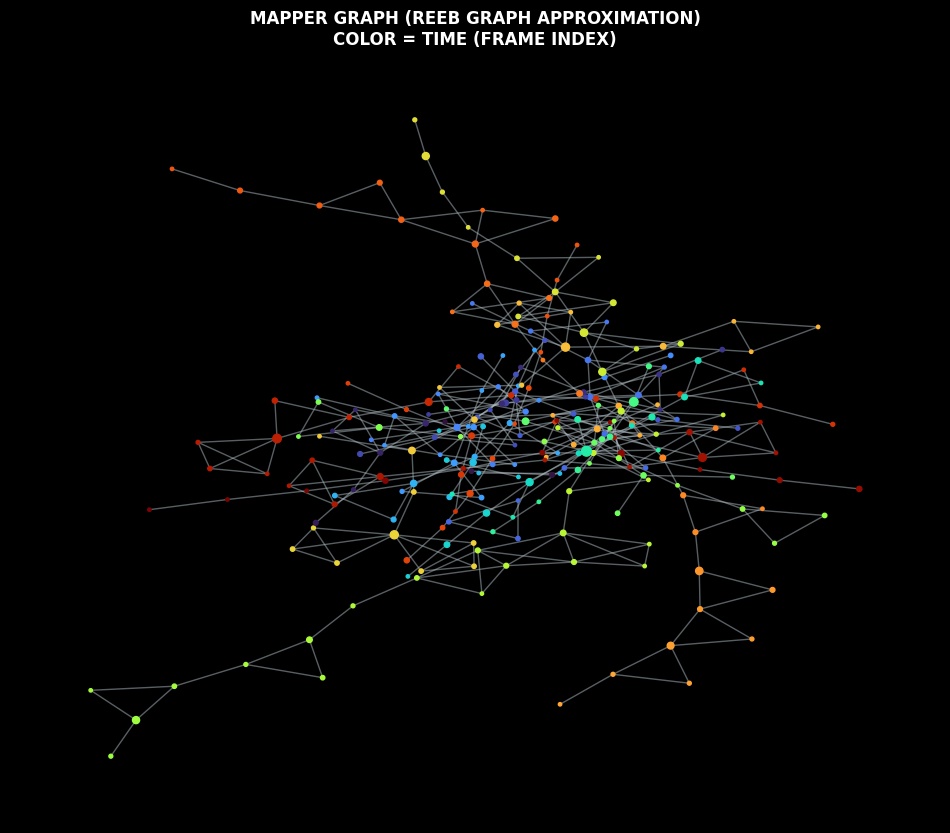

Found 103 cycles in the Mapper graph.
Dominant Cycle has 3 nodes.
Dominant Cycle covers frames: 378 to 393
This suggests a recurrent trajectory within this time window.


In [ ]:
# --- 5. Mapper Algorithm (Reeb Graph) ---
# Visualize the global shape as a graph

print("Running Mapper...")
# Initialize
mapper = km.KeplerMapper(verbose=1)

# Lens: Isomap 1 & 2 (Geodesic coordinates)
lens = mapper.fit_transform(X, projection=[Isomap(n_components=2, n_neighbors=30)])

# Create Graph
# Cover: Overlap amount determines connectivity
# Clusterer: DBSCAN is standard
graph = mapper.map(lens,
                   X,
                   cover=km.Cover(n_cubes=10, perc_overlap=0.3),
                   clusterer=km.cluster.DBSCAN(eps=5.0, min_samples=3))

# Convert to NetworkX for plotting in notebook
nx_graph = km.adapter.to_nx(graph)

# Plot using our style
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(viz_style.BLACK)
ax.set_facecolor(viz_style.BLACK)

pos = nx.kamada_kawai_layout(nx_graph)

# Color nodes by average frame index (Time)
node_colors = []
node_sizes = []
for node in nx_graph.nodes():
    # Mapper nodes contain indices of original points
    indices = graph['nodes'][node]
    avg_frame = np.mean(indices) # Indices correspond to frames in our X
    node_colors.append(avg_frame)
    node_sizes.append(len(indices) * 2)

viz_style.plot_network_graph(
    ax, nx_graph, pos,
    node_colors=node_colors,
    cmap='turbo',
    node_size=node_sizes,
    edge_width=1.0,
    title="MAPPER GRAPH (Reeb Graph Approximation)\nColor = Time (Frame Index)"
)
plt.show()

# --- B. Global Shape Analysis (Cycles) ---
try:
    cycles = nx.cycle_basis(nx_graph)
    print(f"Found {len(cycles)} cycles in the Mapper graph.")
    
    # Sort by length
    cycles.sort(key=len, reverse=True)
    
    if len(cycles) > 0:
        dominant_cycle = cycles[0]
        print(f"Dominant Cycle has {len(dominant_cycle)} nodes.")
        
        # Get time indices for this cycle
        cycle_frames = []
        for node in dominant_cycle:
            indices = graph['nodes'][node]
            cycle_frames.extend(indices)
            
        print(f"Dominant Cycle covers frames: {np.min(cycle_frames)} to {np.max(cycle_frames)}")
        print("This suggests a recurrent trajectory within this time window.")
except Exception as e:
    print(f"Cycle analysis failed: {e}")

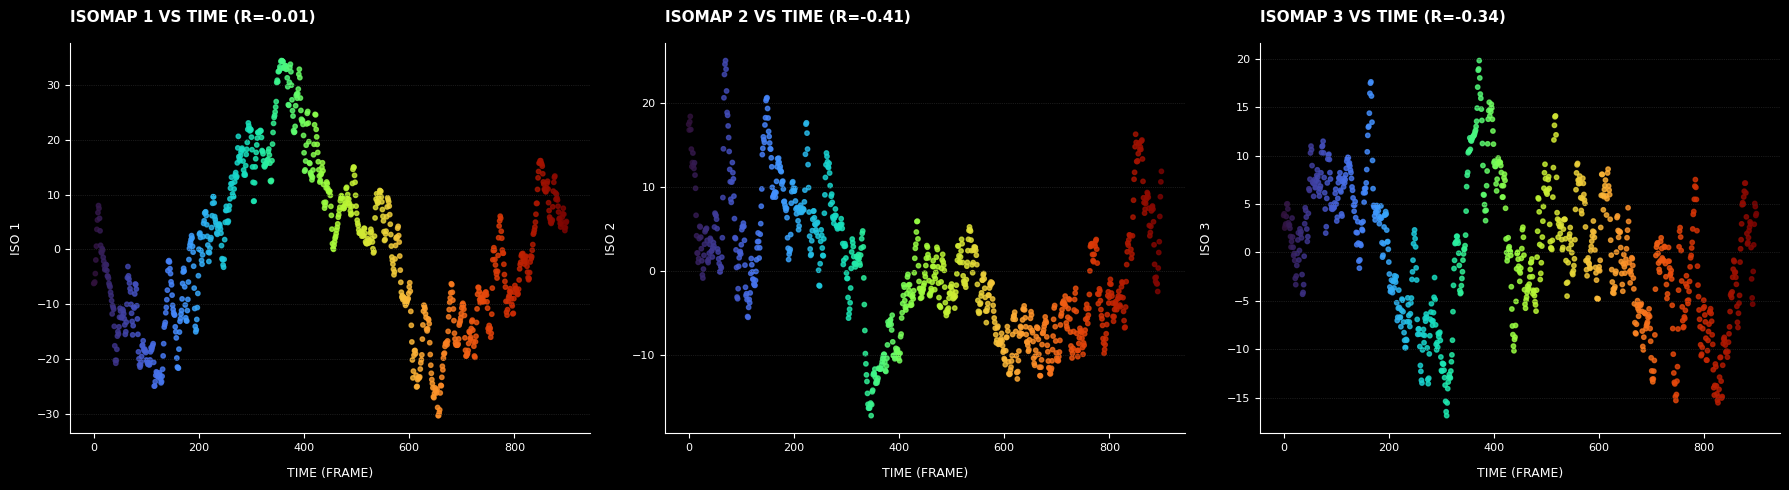

Interpretation:
High correlation indicates the manifold coordinate encodes time/sequence.
Non-monotonic relationships (e.g., U-shape) suggest cyclic or returning dynamics.


In [ ]:
# --- 6. Latent Variable Interpretation ---
# Correlate Isomap coordinates with Time (Frame Index)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(viz_style.BLACK)

time = np.arange(len(X_iso))

for i in range(3):
    ax = axes[i]
    ax.set_facecolor(viz_style.BLACK)
    
    # Scatter plot
    ax.scatter(time, X_iso[:, i], c=time, cmap='turbo', s=10, alpha=0.8)
    
    # Correlation
    corr = np.corrcoef(time, X_iso[:, i])[0, 1]
    
    viz_style.format_axis(ax, title=f"Isomap {i+1} vs Time (r={corr:.2f})", xlabel="Time (Frame)", ylabel=f"Iso {i+1}")

plt.tight_layout()
plt.show()

print("Interpretation:")
print("High correlation indicates the manifold coordinate encodes time/sequence.")
print("Non-monotonic relationships (e.g., U-shape) suggest cyclic or returning dynamics.")

In [ ]:
# --- 7. Behavioral Alignment (Running Speed) ---
# Load Running Speed and align with Neural Data

print("Loading Running Speed...")
try:
    running_speed = session.running_speed
    
    # Interpolate running speed to movie frames
    # Movie frames are in movie_table['start_time']
    frame_times = movie_table['start_time'].values
    speed_interp = np.interp(frame_times, running_speed.timestamps, running_speed.velocity)
    
    # Plot Isomap colored by Speed
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    sc = viz_style.plot_3d_trajectory(
        ax,
        X_iso[:, 0], X_iso[:, 1], X_iso[:, 2],
        c=speed_interp,
        cmap='inferno',
        title="ISOMAP EMBEDDING (Color = Running Speed)",
        xlabel="Iso 1", ylabel="Iso 2", zlabel="Iso 3"
    )
    cbar = plt.colorbar(sc, ax=ax, label="Running Speed (cm/s)")
    cbar.ax.yaxis.label.set_color(viz_style.WHITE)
    cbar.ax.tick_params(colors=viz_style.WHITE)
    plt.show()
    
    # Correlation
    corr_speed = np.corrcoef(speed_interp, X_iso[:, 0])[0, 1]
    print(f"Correlation between Iso 1 and Running Speed: {corr_speed:.2f}")
    
except AttributeError:
    print("Running speed data not available for this session.")
except Exception as e:
    print(f"Error processing running speed: {e}")

Loading Running Speed...
Running speed data not available for this session.
Running speed data not available for this session.
